In [1]:
# 🔧 Setup: Run this cell first!
# Check GPU availability and install dependencies

import torch
import sys

# Check GPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"✅ GPU available: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    device = torch.device('cpu')
    print("⚠️ No GPU detected. Some cells may run slowly.")
    print("   Go to Runtime → Change runtime type → GPU")

print(f"\n📦 Python {sys.version.split()[0]}")
print(f"🔥 PyTorch {torch.__version__}")

# Set random seeds for reproducibility
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"🎲 Random seed set to {SEED}")

%matplotlib inline

✅ GPU available: NVIDIA GB10
   Memory: 130.7 GB

📦 Python 3.11.15
🔥 PyTorch 2.13.0+cu130
🎲 Random seed set to 42


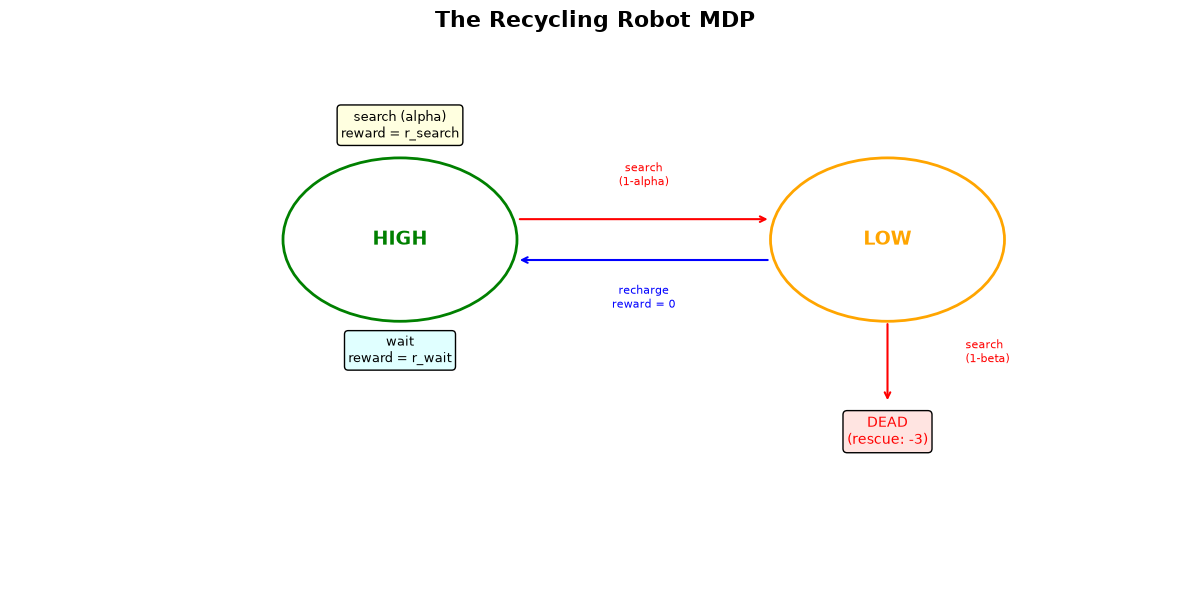

The robot must balance short-term reward (searching) against long-term survival (recharging).


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Visualize the recycling robot decision problem
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.set_xlim(-1, 11)
ax.set_ylim(-1, 7)
ax.axis('off')
ax.set_title('The Recycling Robot MDP', fontsize=16, fontweight='bold')

# Draw states
circle_high = plt.Circle((3, 4), 1.2, fill=False, linewidth=2, color='green')
circle_low = plt.Circle((8, 4), 1.2, fill=False, linewidth=2, color='orange')
ax.add_patch(circle_high)
ax.add_patch(circle_low)
ax.text(3, 4, 'HIGH', ha='center', va='center', fontsize=14, fontweight='bold', color='green')
ax.text(8, 4, 'LOW', ha='center', va='center', fontsize=14, fontweight='bold', color='orange')

# Annotations
ax.annotate('search (alpha)\nreward = r_search', xy=(3, 5.5), fontsize=9, ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))
ax.annotate('wait\nreward = r_wait', xy=(3, 2.2), fontsize=9, ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcyan'))

# Arrow from High to Low
ax.annotate('', xy=(6.8, 4.3), xytext=(4.2, 4.3),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
ax.text(5.5, 4.8, 'search\n(1-alpha)', fontsize=8, ha='center', color='red')

# Arrow from Low to High (recharge)
ax.annotate('', xy=(4.2, 3.7), xytext=(6.8, 3.7),
            arrowprops=dict(arrowstyle='->', color='blue', lw=1.5))
ax.text(5.5, 3.0, 'recharge\nreward = 0', fontsize=8, ha='center', color='blue')

# Dead state
ax.text(8, 1, 'DEAD\n(rescue: -3)', ha='center', fontsize=10, color='red',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='mistyrose'))
ax.annotate('', xy=(8, 1.6), xytext=(8, 2.8),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
ax.text(8.8, 2.2, 'search\n(1-beta)', fontsize=8, color='red')

plt.tight_layout()
plt.show()

print("The robot must balance short-term reward (searching) against long-term survival (recharging).")

In [4]:
# Let us verify each of these mathematically with code

# 1. Compute episodic vs discounted returns
rewards = [1, 2, 3, 4, 5]
gammas = [0.0, 0.5, 0.9, 0.99, 1.0]

print("Reward sequence:", rewards)
print()
print(f"{'gamma':>6} | {'G_0':>8} | Interpretation")
print("-" * 55)

for gamma in gammas:
    G = sum(gamma**k * rewards[k] for k in range(len(rewards)))
    if gamma == 0.0:
        interp = "Only immediate reward matters"
    elif gamma == 1.0:
        interp = "All rewards equally weighted"
    else:
        interp = f"Future rewards discounted by {gamma} per step"
    print(f"{gamma:>6.2f} | {G:>8.3f} | {interp}")

print("\nKey insight: gamma controls the agent's 'patience' for future rewards.")

Reward sequence: [1, 2, 3, 4, 5]

 gamma |      G_0 | Interpretation
-------------------------------------------------------
  0.00 |    1.000 | Only immediate reward matters
  0.50 |    3.562 | Future rewards discounted by 0.5 per step
  0.90 |   11.427 | Future rewards discounted by 0.9 per step
  0.99 |   14.604 | Future rewards discounted by 0.99 per step
  1.00 |   15.000 | All rewards equally weighted

Key insight: gamma controls the agent's 'patience' for future rewards.


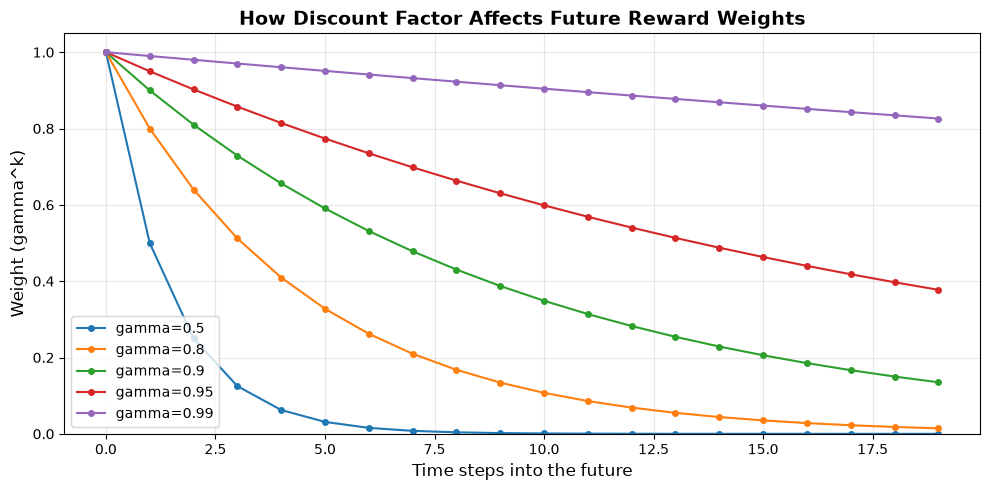

With gamma=0.5, rewards 10 steps away are worth only 0.001 of immediate reward.
With gamma=0.99, rewards 10 steps away are still worth 0.90 of immediate reward.


In [5]:
# 2. Visualize how discounting affects the weight of future rewards
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

timesteps = np.arange(20)
for gamma in [0.5, 0.8, 0.9, 0.95, 0.99]:
    weights = gamma ** timesteps
    ax.plot(timesteps, weights, 'o-', markersize=4, label=f'gamma={gamma}')

ax.set_xlabel('Time steps into the future', fontsize=12)
ax.set_ylabel('Weight (gamma^k)', fontsize=12)
ax.set_title('How Discount Factor Affects Future Reward Weights', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print("With gamma=0.5, rewards 10 steps away are worth only 0.001 of immediate reward.")
print("With gamma=0.99, rewards 10 steps away are still worth 0.90 of immediate reward.")

In [6]:
class MDP:
    """A complete Markov Decision Process implementation."""

    def __init__(self, states, actions, transitions, rewards, gamma=0.9):
        """
        Args:
            states: list of state names
            actions: dict mapping state -> list of available actions
            transitions: dict mapping (state, action) -> list of (next_state, probability)
            rewards: dict mapping (state, action) -> immediate reward
            gamma: discount factor
        """
        self.states = states
        self.actions = actions
        self.transitions = transitions
        self.rewards = rewards
        self.gamma = gamma

    def step(self, state, action):
        """Take action in state, return (next_state, reward)."""
        possible = self.transitions[(state, action)]
        probs = [p for _, p in possible]
        next_states = [s for s, _ in possible]

        # Sample next state according to transition probabilities
        idx = np.random.choice(len(possible), p=probs)
        next_state = next_states[idx]
        reward = self.rewards[(state, action)]

        return next_state, reward

    def get_actions(self, state):
        """Get available actions in a state."""
        return self.actions.get(state, [])

    def print_model(self):
        """Display the full MDP model."""
        print("MDP Model")
        print("=" * 50)
        print(f"States: {self.states}")
        print(f"Gamma: {self.gamma}")
        print()
        for state in self.states:
            if state not in self.actions:
                continue
            print(f"State: {state}")
            for action in self.actions[state]:
                reward = self.rewards[(state, action)]
                print(f"  Action: {action} (reward = {reward})")
                for next_state, prob in self.transitions[(state, action)]:
                    print(f"    -> {next_state} with probability {prob:.2f}")
            print()

print("MDP class defined. Let us create the recycling robot MDP.")

MDP class defined. Let us create the recycling robot MDP.


In [7]:
# Define the recycling robot MDP
alpha = 0.7  # prob of staying high when searching from high
beta = 0.4   # prob of staying low when searching from low
r_search = 2
r_wait = 1

recycling_robot = MDP(
    states=['High', 'Low', 'Dead'],
    actions={
        'High': ['search', 'wait'],
        'Low': ['search', 'wait', 'recharge'],
    },
    transitions={
        ('High', 'search'):   [('High', alpha), ('Low', 1-alpha)],
        ('High', 'wait'):     [('High', 1.0)],
        ('Low', 'search'):    [('Low', beta), ('Dead', 1-beta)],
        ('Low', 'wait'):      [('Low', 1.0)],
        ('Low', 'recharge'):  [('High', 1.0)],
    },
    rewards={
        ('High', 'search'):   r_search,
        ('High', 'wait'):     r_wait,
        ('Low', 'search'):    r_search,  # expected if not dead
        ('Low', 'wait'):      r_wait,
        ('Low', 'recharge'):  0,
    },
    gamma=0.9
)

recycling_robot.print_model()

MDP Model
States: ['High', 'Low', 'Dead']
Gamma: 0.9

State: High
  Action: search (reward = 2)
    -> High with probability 0.70
    -> Low with probability 0.30
  Action: wait (reward = 1)
    -> High with probability 1.00

State: Low
  Action: search (reward = 2)
    -> Low with probability 0.40
    -> Dead with probability 0.60
  Action: wait (reward = 1)
    -> Low with probability 1.00
  Action: recharge (reward = 0)
    -> High with probability 1.00



In [8]:
def simulate_episode(mdp, policy, start_state, max_steps=20):
    """
    Run one episode following a policy.

    Args:
        policy: dict mapping state -> action
        start_state: initial state
        max_steps: maximum steps before truncation
    """
    state = start_state
    trajectory = []
    total_reward = 0

    for t in range(max_steps):
        if state == 'Dead' or state not in mdp.actions:
            break

        action = policy[state]
        next_state, reward = mdp.step(state, action)

        # Special case: if battery dies during search from Low
        if state == 'Low' and action == 'search' and next_state == 'Dead':
            reward = -3  # rescue penalty

        trajectory.append((t, state, action, reward, next_state))
        total_reward += (mdp.gamma ** t) * reward
        state = next_state

    return trajectory, total_reward

# Define two different policies
policy_aggressive = {'High': 'search', 'Low': 'search'}   # always search
policy_cautious = {'High': 'search', 'Low': 'recharge'}    # recharge when low

# Simulate both
np.random.seed(42)
print("AGGRESSIVE POLICY (always search):")
print("-" * 60)
traj_agg, reward_agg = simulate_episode(recycling_robot, policy_aggressive, 'High')
for t, s, a, r, ns in traj_agg:
    print(f"  t={t}: state={s:5s} action={a:10s} reward={r:+.0f} -> {ns}")
print(f"  Discounted return: {reward_agg:.2f}")

print()

np.random.seed(42)
print("CAUTIOUS POLICY (recharge when low):")
print("-" * 60)
traj_cau, reward_cau = simulate_episode(recycling_robot, policy_cautious, 'High')
for t, s, a, r, ns in traj_cau:
    print(f"  t={t}: state={s:5s} action={a:10s} reward={r:+.0f} -> {ns}")
print(f"  Discounted return: {reward_cau:.2f}")

AGGRESSIVE POLICY (always search):
------------------------------------------------------------
  t=0: state=High  action=search     reward=+2 -> High
  t=1: state=High  action=search     reward=+2 -> Low
  t=2: state=Low   action=search     reward=-3 -> Dead
  Discounted return: 1.37

CAUTIOUS POLICY (recharge when low):
------------------------------------------------------------
  t=0: state=High  action=search     reward=+2 -> High
  t=1: state=High  action=search     reward=+2 -> Low
  t=2: state=Low   action=recharge   reward=+0 -> High
  t=3: state=High  action=search     reward=+2 -> High
  t=4: state=High  action=search     reward=+2 -> High
  t=5: state=High  action=search     reward=+2 -> High
  t=6: state=High  action=search     reward=+2 -> High
  t=7: state=High  action=search     reward=+2 -> Low
  t=8: state=Low   action=recharge   reward=+0 -> High
  t=9: state=High  action=search     reward=+2 -> Low
  t=10: state=Low   action=recharge   reward=+0 -> High
  t=11: stat